In [4]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from _src import MLP

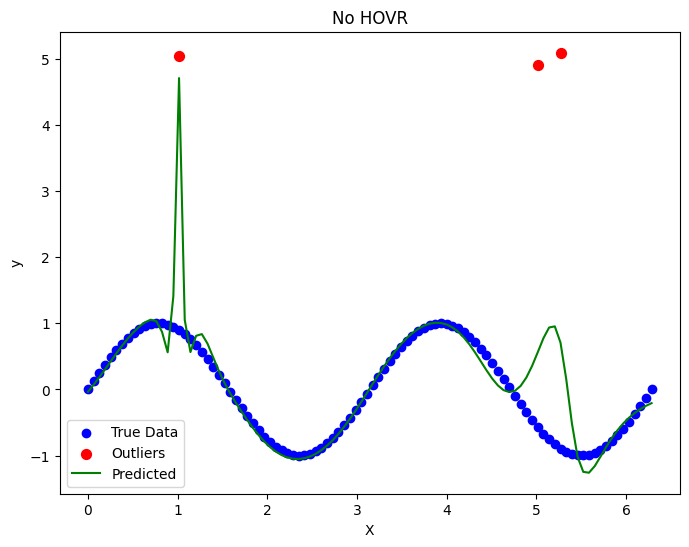

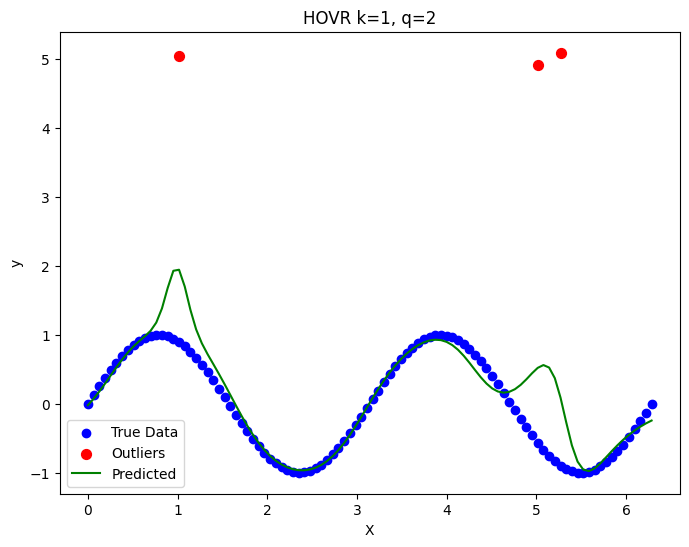

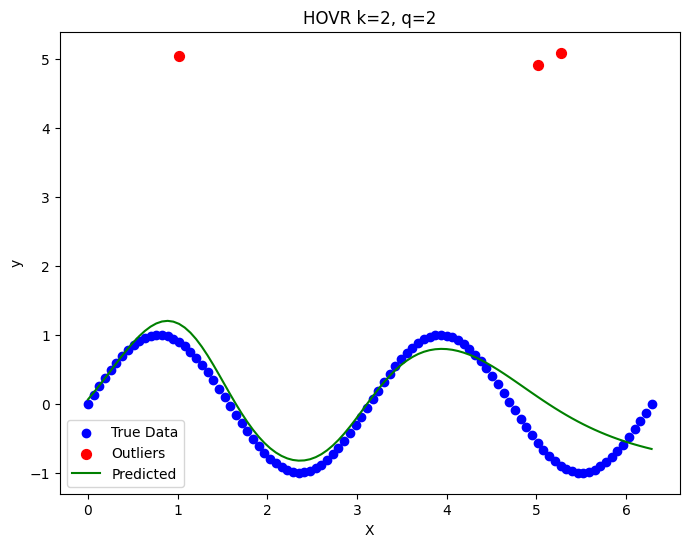

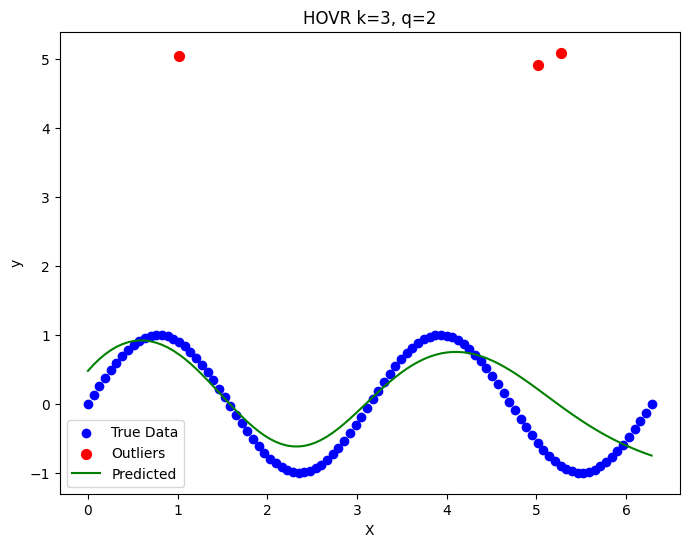

In [7]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt


# 1次元データセットの生成
def generate_data(n=100, noise_std=0.2, outlier_ratio=0.03):
    X = np.linspace(0, 2 * np.pi, n).reshape(-1, 1)
    y_true = np.sin(2 * X).flatten()
    y = y_true + np.random.normal(0, noise_std, X.shape[0])

    # 外れ値の挿入
    n_outliers = int(n * outlier_ratio)
    outlier_indices = np.random.choice(n, n_outliers, replace=False)
    y[outlier_indices] = 5 + np.random.uniform(-0.1, 0.1, n_outliers)

    return X, y, y_true, outlier_indices

# HOVR正則化の定義
def hovr_regularization(model, x, k=2, q=2, num_points=10):
    x_min, x_max = x.min(0)[0], x.max(0)[0]
    random_points = torch.tensor(np.random.uniform(x_min.numpy(), x_max.numpy(), (num_points, x.shape[1])), 
                                 dtype=torch.float32, requires_grad=True)
    preds = model(random_points)
    grads = torch.autograd.grad(preds, random_points, torch.ones_like(preds), create_graph=True)[0]

    hovr_term = 0.0
    for i in range(x.shape[1]):
        grad_i = grads[:, i]
        temp_grad = grad_i
        for _ in range(k - 1):
            temp_grad = torch.autograd.grad(temp_grad, random_points, torch.ones_like(temp_grad), create_graph=True)[0][:, i]
        hovr_term += torch.sum(torch.abs(temp_grad) ** q)
    
    return hovr_term / x.shape[1]

# モデルの訓練
def train_model(X, y, model, optimizer, hovr_lambda=None, hovr_k=None, hovr_q=None, num_epochs=5000):
    X_tensor = torch.tensor(X, dtype=torch.float32)
    y_tensor = torch.tensor(y.reshape(-1, 1), dtype=torch.float32)
    
    for epoch in range(num_epochs):
        optimizer.zero_grad()
        preds = model(X_tensor)
        loss = nn.MSELoss()(preds, y_tensor)
        
        # HOVR正則化を追加
        if hovr_lambda is not None and hovr_k is not None and hovr_q is not None:
            hovr_term = hovr_regularization(model, X_tensor, k=hovr_k, q=hovr_q)
            loss += hovr_lambda * hovr_term

        loss.backward()
        optimizer.step()

# 1次元データの予測結果をプロット
def plot_1d(X, y, predict_func, title, outlier_indices, y_true):
    plt.figure(figsize=(8, 6))
    plt.scatter(X, y_true, color='blue', label='True Data')
    plt.scatter(X[outlier_indices], y[outlier_indices], color='red', label='Outliers', s=50)

    X_grid = np.linspace(0, 2 * np.pi, 100).reshape(-1, 1)
    y_grid_pred = predict_func(X_grid)

    plt.plot(X_grid, y_grid_pred, color='green', label='Predicted')
    plt.xlabel('X')
    plt.ylabel('y')
    plt.title(title)
    plt.legend()
    plt.show()

# 各モデルの訓練とプロット
def train_and_plot(X, y, y_true, outlier_indices, hovr_settings=None, activ=nn.ReLU()):
    model = MLP(input_dim=1, hidden_dim=128, output_dim=1, activation_func=activ)
    optimizer = optim.Adam(model.parameters(), lr=0.01, weight_decay=1e-4)  # L2正則化追加

    if hovr_settings is None:
        train_model(X, y, model, optimizer, num_epochs=5000)
    else:
        hovr_lambda, hovr_k, hovr_q = hovr_settings
        train_model(X, y, model, optimizer, hovr_lambda=hovr_lambda, hovr_k=hovr_k, hovr_q=hovr_q, num_epochs=5000)

    predict_func = lambda X_new: model(torch.tensor(X_new, dtype=torch.float32)).detach().numpy().flatten()
    title = f"HOVR k={hovr_k}, q={hovr_q}" if hovr_settings else "No HOVR"
    plot_1d(X, y, predict_func, title, outlier_indices, y_true)

# 使用例
if __name__ == "__main__":
    X, y, y_true, outlier_indices = generate_data()

    # 通常のモデル (HOVRなし)
    train_and_plot(X, y, y_true, outlier_indices)

    # (1, 2)-VR
    train_and_plot(X, y, y_true, outlier_indices, hovr_settings=(1e-3, 1, 2))

    # (2, 2)-VR
    train_and_plot(X, y, y_true, outlier_indices, hovr_settings=(1e-3, 2, 2))

    # (3, 2)-VR
    train_and_plot(X, y, y_true, outlier_indices, hovr_settings=(1e-3, 3, 2))


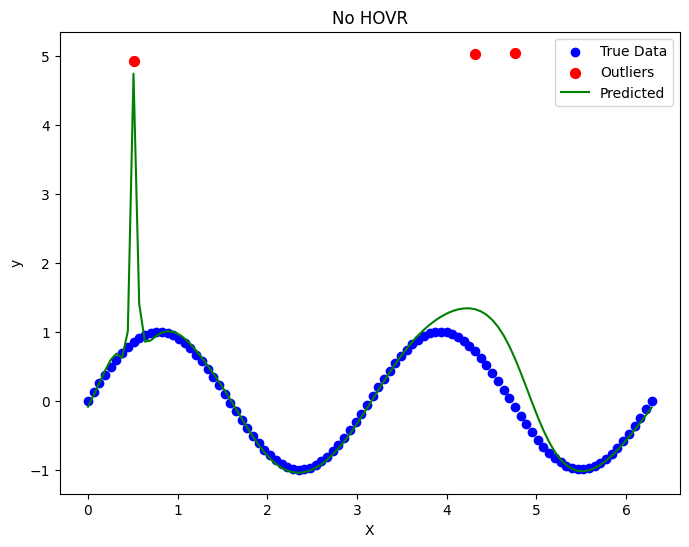

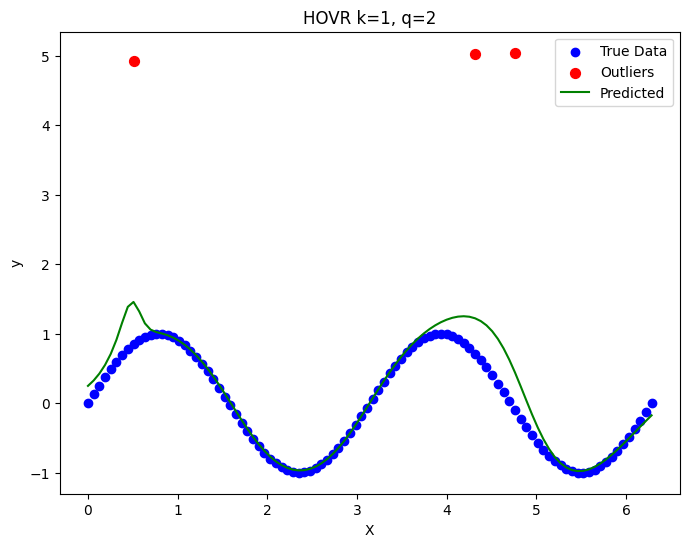

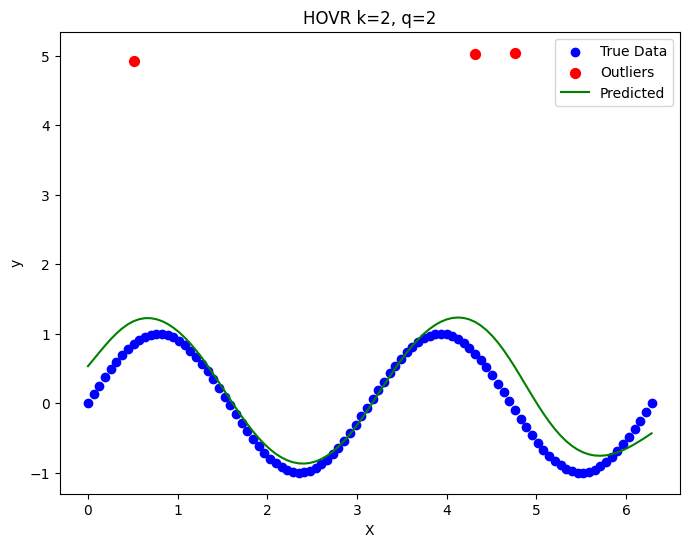

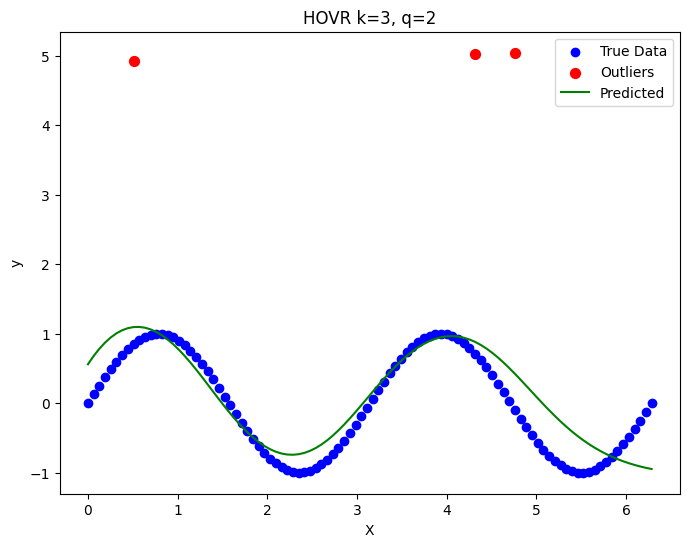

In [8]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt


# 1次元データセットの生成
def generate_data(n=100, noise_std=0.2, outlier_ratio=0.03):
    X = np.linspace(0, 2 * np.pi, n).reshape(-1, 1)
    y_true = np.sin(2 * X).flatten()
    y = y_true + np.random.normal(0, noise_std, X.shape[0])

    # 外れ値の挿入
    n_outliers = int(n * outlier_ratio)
    outlier_indices = np.random.choice(n, n_outliers, replace=False)
    y[outlier_indices] = 5 + np.random.uniform(-0.1, 0.1, n_outliers)

    return X, y, y_true, outlier_indices

# HOVR正則化の定義
def hovr_regularization(model, x, k=2, q=2, num_points=10):
    x_min, x_max = x.min(0)[0], x.max(0)[0]
    random_points = torch.tensor(np.random.uniform(x_min.numpy(), x_max.numpy(), (num_points, x.shape[1])), 
                                 dtype=torch.float32, requires_grad=True)
    preds = model(random_points)
    grads = torch.autograd.grad(preds, random_points, torch.ones_like(preds), create_graph=True)[0]

    hovr_term = 0.0
    for i in range(x.shape[1]):
        grad_i = grads[:, i]
        temp_grad = grad_i
        for _ in range(k - 1):
            temp_grad = torch.autograd.grad(temp_grad, random_points, torch.ones_like(temp_grad), create_graph=True)[0][:, i]
        hovr_term += torch.sum(torch.abs(temp_grad) ** q)
    
    return hovr_term / x.shape[1]

# モデルの訓練
def train_model(X, y, model, optimizer, hovr_lambda=None, hovr_k=None, hovr_q=None, num_epochs=5000):
    X_tensor = torch.tensor(X, dtype=torch.float32)
    y_tensor = torch.tensor(y.reshape(-1, 1), dtype=torch.float32)
    
    for epoch in range(num_epochs):
        optimizer.zero_grad()
        preds = model(X_tensor)
        loss = nn.MSELoss()(preds, y_tensor)
        
        # HOVR正則化を追加
        if hovr_lambda is not None and hovr_k is not None and hovr_q is not None:
            hovr_term = hovr_regularization(model, X_tensor, k=hovr_k, q=hovr_q)
            loss += hovr_lambda * hovr_term

        loss.backward()
        optimizer.step()

# 1次元データの予測結果をプロット
def plot_1d(X, y, predict_func, title, outlier_indices, y_true):
    plt.figure(figsize=(8, 6))
    plt.scatter(X, y_true, color='blue', label='True Data')
    plt.scatter(X[outlier_indices], y[outlier_indices], color='red', label='Outliers', s=50)

    X_grid = np.linspace(0, 2 * np.pi, 100).reshape(-1, 1)
    y_grid_pred = predict_func(X_grid)

    plt.plot(X_grid, y_grid_pred, color='green', label='Predicted')
    plt.xlabel('X')
    plt.ylabel('y')
    plt.title(title)
    plt.legend()
    plt.show()

# 各モデルの訓練とプロット
def train_and_plot(X, y, y_true, outlier_indices, hovr_settings=None, activ=nn.ReLU()):
    model = MLP(input_dim=1, hidden_dim=128, output_dim=1, activation_func=activ)
    optimizer = optim.Adam(model.parameters(), lr=0.01, weight_decay=1e-4)  # L2正則化追加

    if hovr_settings is None:
        train_model(X, y, model, optimizer, num_epochs=5000)
    else:
        hovr_lambda, hovr_k, hovr_q = hovr_settings
        train_model(X, y, model, optimizer, hovr_lambda=hovr_lambda, hovr_k=hovr_k, hovr_q=hovr_q, num_epochs=5000)

    predict_func = lambda X_new: model(torch.tensor(X_new, dtype=torch.float32)).detach().numpy().flatten()
    title = f"HOVR k={hovr_k}, q={hovr_q}" if hovr_settings else "No HOVR"
    plot_1d(X, y, predict_func, title, outlier_indices, y_true)

# 使用例
if __name__ == "__main__":
    X, y, y_true, outlier_indices = generate_data()

    # 通常のモデル (HOVRなし)
    train_and_plot(X, y, y_true, outlier_indices, activ=nn.Sigmoid())

    # (1, 2)-VR
    train_and_plot(X, y, y_true, outlier_indices, hovr_settings=(1e-3, 1, 2), activ=nn.Sigmoid())

    # (2, 2)-VR
    train_and_plot(X, y, y_true, outlier_indices, hovr_settings=(1e-3, 2, 2), activ=nn.Sigmoid())

    # (3, 2)-VR
    train_and_plot(X, y, y_true, outlier_indices, hovr_settings=(1e-3, 3, 2), activ=nn.Sigmoid())
